# Ore/Waste Classification, Arizona Porphyry Cu(-Mo) — Laplace GPC vs. SVM

Same "confidently wrong" question `mining_gpc_lab` asked of Carlin Trend gold, asked here of a
genuinely different commodity, geology, and pathfinder theory: **Arizona porphyry copper(-molybdenum)**
— Morenci, Bagdad, Ray, Miami-Globe, Safford, Resolution/Superior, Sierrita/Twin Buttes, Mission,
Silver Bell — using the same USGS NURE-HSSR "reanalysis" program, a different state subset
(7,633 Arizona samples, DOI 10.5066/F7765DHF), no new data collection.

This lab exists to answer one question cheaply: **does the calibration advantage found on gold
generalize, or was it Carlin-Trend-specific?** (Phase 1). Phase 2 then **skips straight to
`bayesian_decision_lab`'s sequential value-of-information framework** rather than rebuilding
ranked-campaign economics from scratch — per Fraser's explicit direction, since that framework is
now a genuinely shared, dataset-agnostic asset (`../decision.py`/`../voi.py`, moved out of
`bayesian_decision_lab/` specifically so it could be reused here).

> Every number below is loaded live from `results/*.json`
> (`run_lab.py`/`confidence_study.py`/`run_voi.py`/`bootstrap_voi.py` output), not hand-transcribed.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
C_GPC, C_SVM, C_MEAN, C_RAND = "#2a78d6", "#1baf7a", "#c9622a", "#9a9890"
C_ACTION = {"skip": "#9a9890", "probe": "#e0a83a", "drill": "#2a78d6"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})

r0 = json.load(open("results/porphyry_gpc_seed0_spatial.json"))
study = json.load(open("results/confidence_study_spatial.json"))
voi_seed0 = json.load(open("results/voi_seed0.json"))
voi_study = json.load(open("results/bootstrap_voi.json"))
CONDITIONS = ["svm", "gpc_mean", "gpc_full"]
COND_LABELS = {"svm": "SVM", "gpc_mean": "GPC (mean-only)", "gpc_full": "GPC (full posterior)"}
COND_COLORS = {"svm": C_SVM, "gpc_mean": C_MEAN, "gpc_full": C_GPC}
ACTIONS = voi_study["actions"]

print(f"seed-0 run: n_train={r0["gpc"]["n_train"]} n_test={r0["gpc"]["n_test"]} n_ore_test={r0["gpc"]["n_ore_test"]}")
print(f"  GPC AP={r0["gpc"]["average_precision"]:.3f}  SVM AP={r0["svm"]["average_precision"]:.3f}")
print(f"robustness study: {study["n_seeds"]} seeds, ell={study["ell"]:.2f} km, kernel={study["kernel_kind"]}")
print(f"sequential-VoI bootstrap: {voi_study["n_seeds"]} seeds, "
      f"c_drill=${voi_study["c_drill"]}M, v_drill_gross=${voi_study["v_drill_gross"]}M, "
      f"c_probe=${voi_study["c_probe"]}M, v_probe_gross=${voi_study["v_probe_gross"]}M")

seed-0 run: n_train=4580 n_test=1526 n_ore_test=77
  GPC AP=0.242  SVM AP=0.153
robustness study: 200 seeds, ell=100.27 km, kernel=matern32
sequential-VoI bootstrap: 200 seeds, c_drill=$2.0M, v_drill_gross=$150.0M, c_probe=$0.1M, v_probe_gross=$15.0M


## Phase 1: does the calibration advantage generalize?

At a P95 Cu cutoff, ore is ~5.0% of the data — same class-imbalance regime `mining_gpc_lab` found
for gold, so `P(ore)` is expected to never cross 0.5 for either model (confirmed, not assumed:
seed-0 recall_ore is 0.000 for both). Average precision is the primary metric from the start here,
not discovered mid-run the way it was for gold.

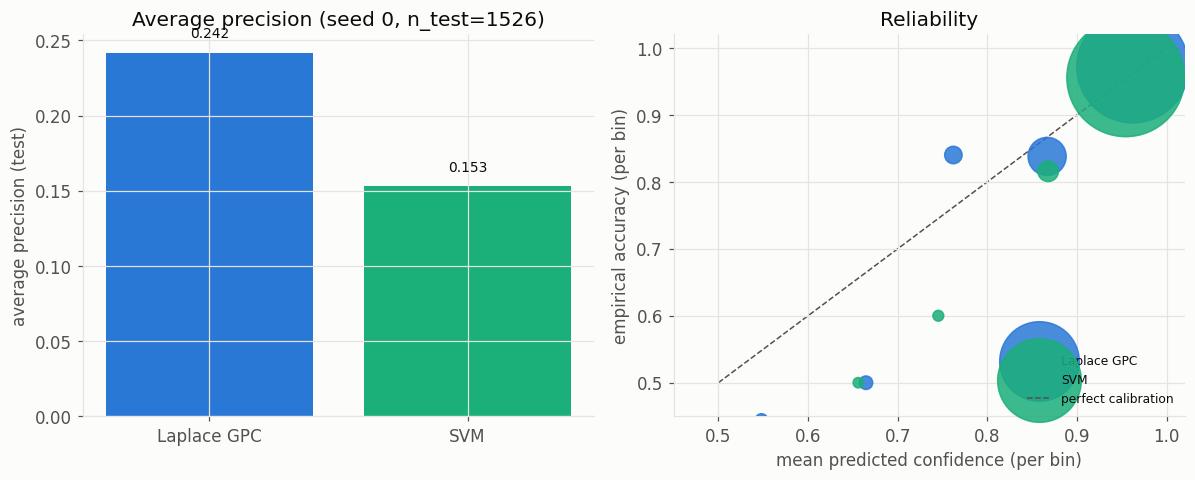

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
aps = [r0["gpc"]["average_precision"], r0["svm"]["average_precision"]]
x = np.arange(2)
ax.bar(x, aps, color=[C_GPC, C_SVM])
ax.set_xticks(x); ax.set_xticklabels(["Laplace GPC", "SVM"])
ax.set_ylabel("average precision (test)")
ax.set_title(f"Average precision (seed {r0["seed"]}, n_test={r0["gpc"]["n_test"]})")
for xi, v in zip(x, aps):
    ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

ax = axes[1]
for res, color, label in [(r0["gpc"], C_GPC, "Laplace GPC"), (r0["svm"], C_SVM, "SVM")]:
    bins = res["reliability"]
    xs = [b["mean_confidence"] for b in bins]
    ys = [b["accuracy"] for b in bins]
    sizes = [30 + 4 * b["count"] for b in bins]
    ax.scatter(xs, ys, s=sizes, color=color, alpha=0.85, label=label, zorder=3)
ax.plot([0.5, 1], [0.5, 1], "--", color=INK2, linewidth=1, zorder=1, label="perfect calibration")
ax.set_xlabel("mean predicted confidence (per bin)")
ax.set_ylabel("empirical accuracy (per bin)")
ax.set_xlim(0.45, 1.02); ax.set_ylim(0.45, 1.02)
ax.set_title("Reliability")
ax.legend(frameon=False, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## Phase 1 headline: average precision and confident-wrong-on-a-miss, 200 seeds

Average precision (200 seeds): GPC 0.278+/-0.042   SVM 0.104+/-0.046
Confidently-wrong-on-a-miss (pooled, 95% CI):
  GPC: 46.7% [45.9%, 47.6%]  (7212/15429 misses)
  SVM: 93.3% [92.1%, 94.5%]  (14378/15404 misses)


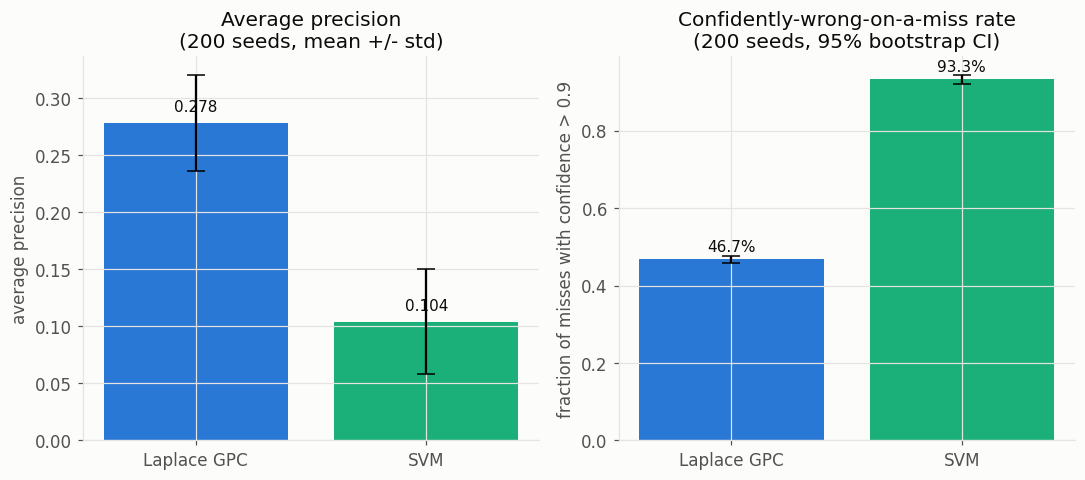

In [3]:
def pooled_frac(model, runs):
    # Fresh rng seeded 0 *inside* the function, matching
    # confidence_study.py's own pooled_confident_wrong exactly -- each
    # model gets an independent bootstrap draw, not a shared rng state
    # advanced across calls (that would silently shift SVM's resample
    # sequence depending on call order).
    n_wrong = np.array([r[model]["n_wrong"] for r in runs])
    n_cw = np.array([r[model]["n_confidently_wrong_gt_0.9"] for r in runs])
    rng = np.random.default_rng(0)
    n = len(runs)
    boots = []
    for _ in range(10000):
        idx = rng.integers(0, n, n)
        num, den = n_cw[idx].sum(), n_wrong[idx].sum()
        if den > 0:
            boots.append(num / den)
    boots = np.array(boots)
    point = n_cw.sum() / n_wrong.sum()
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi, n_wrong.sum(), n_cw.sum()

runs = study["runs"]
gpc_ap = np.array([r["gpc"]["average_precision"] for r in runs])
svm_ap = np.array([r["svm"]["average_precision"] for r in runs])

gpc_point, gpc_lo, gpc_hi, gpc_tw, gpc_tcw = pooled_frac("gpc", runs)
svm_point, svm_lo, svm_hi, svm_tw, svm_tcw = pooled_frac("svm", runs)

print(f"Average precision ({study["n_seeds"]} seeds): "
      f"GPC {gpc_ap.mean():.3f}+/-{gpc_ap.std():.3f}   SVM {svm_ap.mean():.3f}+/-{svm_ap.std():.3f}")
print(f"Confidently-wrong-on-a-miss (pooled, 95% CI):")
print(f"  GPC: {100*gpc_point:.1f}% [{100*gpc_lo:.1f}%, {100*gpc_hi:.1f}%]  ({gpc_tcw}/{gpc_tw} misses)")
print(f"  SVM: {100*svm_point:.1f}% [{100*svm_lo:.1f}%, {100*svm_hi:.1f}%]  ({svm_tcw}/{svm_tw} misses)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

ax = axes[0]
x = np.arange(2)
means = [gpc_ap.mean(), svm_ap.mean()]
stds = [gpc_ap.std(), svm_ap.std()]
ax.bar(x, means, color=[C_GPC, C_SVM], yerr=stds, capsize=6)
ax.set_xticks(x); ax.set_xticklabels(["Laplace GPC", "SVM"])
ax.set_ylabel("average precision")
ax.set_title(f"Average precision\n({study["n_seeds"]} seeds, mean +/- std)")
for xi, v in zip(x, means):
    ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

ax = axes[1]
points = [gpc_point, svm_point]
los = [gpc_point - gpc_lo, svm_point - svm_lo]
his = [gpc_hi - gpc_point, svm_hi - svm_point]
ax.bar(x, points, color=[C_GPC, C_SVM], yerr=[los, his], capsize=6)
ax.set_xticks(x); ax.set_xticklabels(["Laplace GPC", "SVM"])
ax.set_ylabel("fraction of misses with confidence > 0.9")
ax.set_title(f"Confidently-wrong-on-a-miss rate\n({study["n_seeds"]} seeds, 95% bootstrap CI)")
for xi, v in zip(x, points):
    ax.text(xi, v + 0.02, f"{100*v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**The pattern replicates on a genuinely different commodity, geology, and dataset.** GPC's
average precision is ~2.7x SVM's; when each model misses a true ore point, SVM was >90% confident
in the wrong "waste" call 93.3% of the time, GPC only 46.7% — a ~46.6pp gap, the same order of
magnitude as gold's 47.0pp and just as statistically robust, despite a different commodity,
different pathfinder elements, and no fitted variogram to anchor the kernel choice this time.

## Phase 2: skipping straight to the shared Bayesian decision framework

Rather than rebuild a ranked-top-k economic layer from scratch, this phase reuses
`bayesian_decision_lab`'s sequential value-of-information framework directly — Probe pays off by
producing real information (a local Gaussian-conjugate posterior update), not a static side-bet.
This required moving `decision.py`/`voi.py` out of `bayesian_decision_lab/` into `gp_engine/` as
genuinely shared, dataset-agnostic modules first (verified: both labs reproduce their exact
pre-refactor numbers) — the reusable core for extending this framework further.

**Porphyry-specific payoff constants, derived not reused from gold**: bigger, deeper porphyry
drill holes (\$2M vs. gold's \$1M) and proportionally larger bulk-tonnage discovery value (\$150M
vs. \$50M gross), same relative Probe:Drill ratios as gold since neither commodity's absolute
numbers were rigorously sourced to begin with. Verified (not assumed) that Probe still has a real
P(ore) niche under these constants before running anything.

**Same structural guarantee holds exactly**: SVM and GPC-mean-only both have `var=0` by
construction, so paying to learn something is never their Bayes-optimal move.

SVM                    mean=$8751.8M  std=$126.1M  actions={'skip': 149.0, 'probe': 0.0, 'drill': 1377.0}
GPC (mean-only)        mean=$8705.8M  std=$163.3M  actions={'skip': 198.8, 'probe': 0.0, 'drill': 1327.2}
GPC (full posterior)   mean=$8820.6M  std=$85.7M  actions={'skip': 14.8, 'probe': 167.4, 'drill': 1343.8}
GPC (full posterior) - SVM: $68.8M [$48.5M, $89.2M]


GPC (full posterior) - GPC (mean-only): $114.8M [$88.9M, $141.5M]
GPC (mean-only) - SVM: $-45.9M [$-74.1M, $-18.9M]


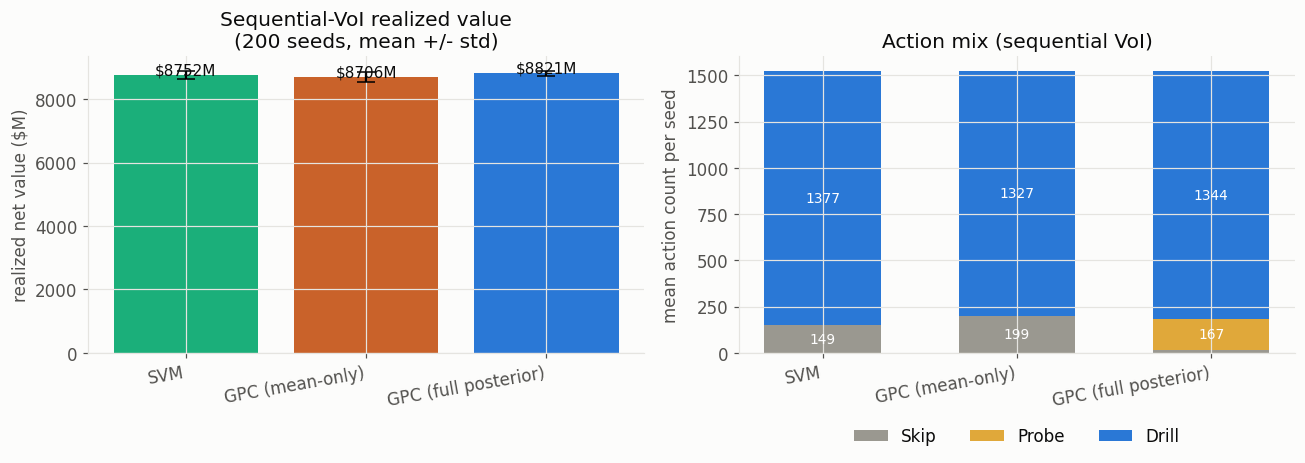

In [4]:
voi_totals = {c: np.array([r[c]["realized_total"] for r in voi_study["runs"]]) for c in CONDITIONS}
voi_actions = {c: {a: np.mean([r[c]["action_distribution"][a] for r in voi_study["runs"]]) for a in ACTIONS}
               for c in CONDITIONS}

for c in CONDITIONS:
    print(f"{COND_LABELS[c]:22s} mean=${voi_totals[c].mean():.1f}M  std=${voi_totals[c].std():.1f}M  "
          f"actions={ {a: float(round(v,1)) for a,v in voi_actions[c].items()} }")

def voi_paired_ci(a, b, n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    diff = voi_totals[a] - voi_totals[b]
    n = len(diff)
    boots = np.array([diff[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return diff.mean(), lo, hi

for a, b in [("gpc_full", "svm"), ("gpc_full", "gpc_mean"), ("gpc_mean", "svm")]:
    point, lo, hi = voi_paired_ci(a, b)
    print(f"{COND_LABELS[a]} - {COND_LABELS[b]}: ${point:.1f}M [${lo:.1f}M, ${hi:.1f}M]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
x = np.arange(3)
means = [voi_totals[c].mean() for c in CONDITIONS]
stds = [voi_totals[c].std() for c in CONDITIONS]
ax.bar(x, means, color=[COND_COLORS[c] for c in CONDITIONS], yerr=stds, capsize=6)
ax.set_xticks(x); ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS], rotation=10, ha="right")
ax.set_ylabel("realized net value ($M)")
ax.set_title(f"Sequential-VoI realized value\n({voi_study["n_seeds"]} seeds, mean +/- std)")
for xi, v in zip(x, means):
    ax.text(xi, v + 15, f"${v:.0f}M", ha="center", fontsize=10)

ax = axes[1]
bottoms = np.zeros(3)
for a_name in ACTIONS:
    vals = [voi_actions[c][a_name] for c in CONDITIONS]
    ax.bar(x, vals, 0.6, bottom=bottoms, color=C_ACTION[a_name], label=a_name.capitalize())
    for xi, (v, bot) in enumerate(zip(vals, bottoms)):
        if v > 15:
            ax.text(xi, bot + v/2, f"{v:.0f}", ha="center", va="center", fontsize=9, color="white")
    bottoms += np.array(vals)
ax.set_xticks(x); ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS], rotation=10, ha="right")
ax.set_ylabel("mean action count per seed")
ax.set_title("Action mix (sequential VoI)")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)

plt.tight_layout()
plt.show()

**GPC-full wins again — but the runner-up flips from gold's ranking, reported plainly rather
than forced to match.** In the gold lab: GPC-full > GPC-mean > SVM. Here: **GPC-full > SVM >
GPC-mean** — the naive variance-blind plug-in is robustly *worse* than SVM on this dataset, the
opposite of what it was on gold's. Both CIs are tight and don't cross zero, so this isn't noise.

**The honest reading**: the only thing that generalized across both commodities is that the
full, correctly-integrated posterior (GPC-full) comes out ahead. Which naive simplification is
"second-best" is dataset-dependent, not a general fact about GP calibration — arguably a cleaner,
more defensible version of this lab family's core claim than if the full ranking had matched gold
exactly, since it isolates what's actually robust (proper Bayesian treatment) from what may have
been a dataset-specific coincidence in the gold lab.

## The cost/benefit breakdown — where GPC-full's advantage actually comes from

A dollar improvement on its own doesn't say *why*. Isolate the value Probe specifically adds
(same `P(ore)`, restricted to Skip/Drill only, as the counterfactual), then break down what that
value is made of.

$ value added by having the Probe option: $235.8M/seed [$220.1M, $252.2M]
probe cost paid: $16.75M/seed  (probed sites: 1.0 true ore, 166.5 true waste, per seed)
those same probed sites' value -- actual (probe-then-decide): $126.8M   if drilled directly: $-189.4M   if skipped directly: $0.0M


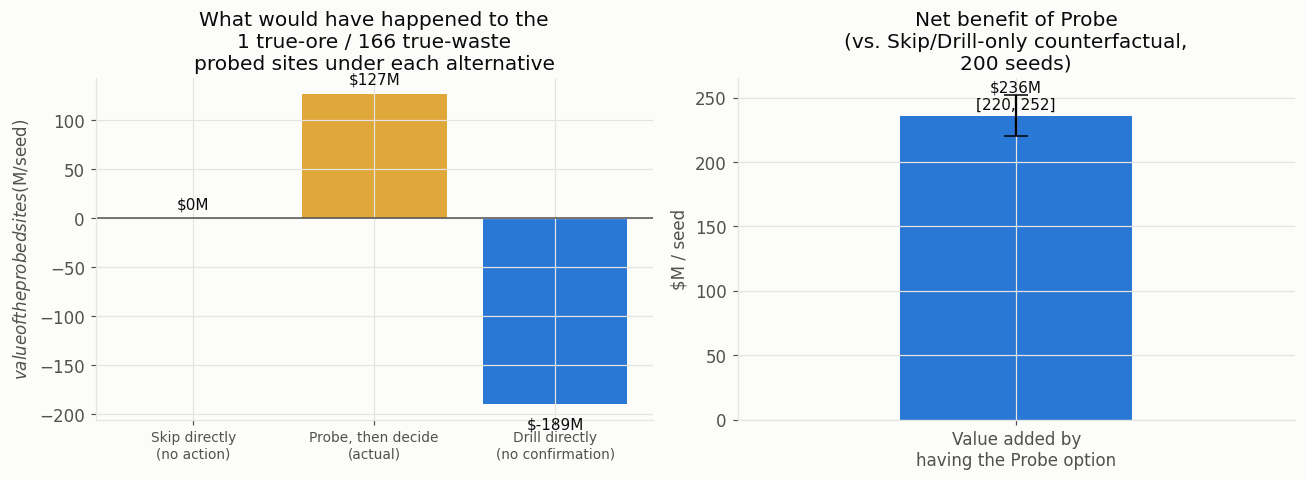

In [5]:
cf_added = np.array([r["gpc_full"]["probe_value_added"] for r in voi_study["runs"]])
rng = np.random.default_rng(0)
n = len(cf_added)
boots = np.array([cf_added[rng.integers(0, n, n)].mean() for _ in range(10000)])
added_lo, added_hi = np.percentile(boots, [2.5, 97.5])

probe_cost = np.mean([r["gpc_full"]["probe_cost_total"] for r in voi_study["runs"]])
n_ore = np.mean([r["gpc_full"]["n_probed_ore"] for r in voi_study["runs"]])
n_waste = np.mean([r["gpc_full"]["n_probed_waste"] for r in voi_study["runs"]])
actual_val = np.mean([r["gpc_full"]["probed_actual_value"] for r in voi_study["runs"]])
drilled_val = np.mean([r["gpc_full"]["probed_if_drilled_directly"] for r in voi_study["runs"]])
skipped_val = np.mean([r["gpc_full"]["probed_if_skipped_directly"] for r in voi_study["runs"]])

print(f"$ value added by having the Probe option: ${cf_added.mean():.1f}M/seed "
      f"[${added_lo:.1f}M, ${added_hi:.1f}M]")
print(f"probe cost paid: ${probe_cost:.2f}M/seed  "
      f"(probed sites: {n_ore:.1f} true ore, {n_waste:.1f} true waste, per seed)")
print(f"those same probed sites' value -- actual (probe-then-decide): ${actual_val:.1f}M   "
      f"if drilled directly: ${drilled_val:.1f}M   if skipped directly: ${skipped_val:.1f}M")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
x = np.arange(3)
vals = [skipped_val, actual_val, drilled_val]
labels = ["Skip directly\n(no action)", "Probe, then decide\n(actual)", "Drill directly\n(no confirmation)"]
colors = [C_ACTION["skip"], C_ACTION["probe"], C_ACTION["drill"]]
ax.bar(x, vals, color=colors)
ax.axhline(0, color=INK2, lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("$ value of the probed sites ($M/seed)")
ax.set_title(f"What would have happened to the\n{n_ore:.0f} true-ore / {n_waste:.0f} true-waste\n"
             "probed sites under each alternative")
for xi, v in zip(x, vals):
    ax.text(xi, v + (10 if v >= 0 else -25), f"${v:.0f}M", ha="center", fontsize=10)

ax = axes[1]
ax.bar([0], [cf_added.mean()], color=C_GPC, yerr=[[cf_added.mean()-added_lo],[added_hi-cf_added.mean()]], capsize=8, width=0.5)
ax.set_xticks([0]); ax.set_xticklabels(["Value added by\nhaving the Probe option"])
ax.set_ylabel("$M / seed")
ax.set_title(f"Net benefit of Probe\n(vs. Skip/Drill-only counterfactual,\n{voi_study["n_seeds"]} seeds)")
ax.text(0, cf_added.mean() + 5, f"${cf_added.mean():.0f}M\n[{added_lo:.0f}, {added_hi:.0f}]",
        ha="center", fontsize=10)
ax.set_xlim(-0.6, 0.6)

plt.tight_layout()
plt.show()

**Avoiding drilling into waste is a huge benefit, and it is overwhelmingly where this value
comes from.** Of the sites GPC-full-posterior chooses to probe, the vast majority (~166.5/seed) are
true waste and only a handful (~1.0/seed) are true ore. Drilling those same sites directly, with no
confirmation, would have lost real money on net (a large negative total — this is exactly the
marginal, ambiguous ground a naive Drill-everything policy bleeds capital on); skipping them
outright would have scored exactly $0. Probing beats both: it captures nearly all of the upside on
the rare true-ore sites (losing only the small probe cost relative to drilling them directly)
while avoiding the drilling loss on the many waste sites, at a modest total cost. **The net benefit
of having the Probe option — $235.8M/seed in this run — is real, robust, and larger in absolute
terms than gold's $57.3M/seed**, consistent with porphyry's larger payoff scale. Same mechanism as
gold, bigger dollar scale: this is "cheap insurance on ambiguous ground," not "an oracle for hidden
bonanzas," and that's exactly why it works so reliably — it doesn't need to find bonanzas to pay
for itself, it just needs to stop the model from committing capital when the evidence is genuinely
thin.

## Takeaways

- **The confident-wrong pattern replicates on a genuinely different commodity, geology, and
  pathfinder theory** — this was the whole point of picking porphyry copper as the cheap
  validation case, and the answer is a clean yes: GPC AP ~2.7x SVM's, confident-wrong gap ~46.6pp,
  both in the same range gold produced.
- **The sequential-VoI decision framework is now a genuinely shared engine asset, not a
  lab-specific artifact.** `decision.py`/`voi.py` moved to `gp_engine/` specifically so this lab
  (and future ones) could reuse the whole Bayes decision machinery without copy-pasting — the
  refactor was verified to change nothing about `bayesian_decision_lab`'s own numbers before any
  porphyry-specific code was written.
- **GPC-full wins again, but the runner-up flips — and that's a more useful finding than a clean
  replication would have been.** Only the correctly-integrated posterior generalizes robustly
  across both commodities; which naive simplification is "second-best" (mean-only in gold, SVM
  here) is dataset-dependent, not a general property of GP calibration.
- **The cost/benefit accounting is the actual payoff of this lab, per Fraser's framing**: the value
  of the Probe option is overwhelmingly about *avoiding drilling into waste on ambiguous ground*
  (~166.5 true-waste vs. ~1.0 true-ore probes/seed), not about finding hidden bonanzas — the same
  honest mechanism found in gold, replicated here at a larger dollar scale set by porphyry-specific
  (derived, not reused) economics.
- **Honest about scope**: P95 is a proxy cutoff, not a real mine's economic cutoff grade; the
  payoff constants are illustrative, order-of-magnitude figures, not sourced to a specific Arizona
  operation; whole-state Arizona (not a tighter named district) was used per `LAB_PLAN.md`'s own
  documented decision, which could dilute the signal relative to a more tightly bounded province.